# Team 2 Project Draft Code IST 360

## Cleaning the Data

In [1]:
#add data dictionary 

# Import pandas for working with tabular data
import pandas as pd

# Import numpy for missing values and numerical utilities
import numpy as np

# Import matplotlib for simple charts
import matplotlib.pyplot as plt

# Import re for text cleaning patterns
import re

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


# Set a display option so we can see more columns when printing tables
pd.set_option("display.max_columns", None)

# Set a display option so wider text values are easier to inspect
pd.set_option("display.width", 140)

# =========================
# Team 1 and 2, remove or add # to load your dataset.
# =========================
# path = "bank-full.csv"
# df = pd.read_csv(path, sep=";")

path = "bank-full.csv"
df = pd.read_csv(path, sep=";")

# =========================
# 1) Basic shape + structure
# =========================
print("Shape (rows, cols):", df.shape)
print("\nColumns:", df.columns.tolist())

print("\nDtypes:")
print(df.dtypes)

print("\nHead:")
display(df.head(5))

print("\nTail:")
display(df.tail(5))

print("\nInfo:")
df.info()

Shape (rows, cols): (45211, 17)

Columns: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']

Dtypes:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

Head:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no



Tail:


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [2]:
# =========================
# 2) Missing values (counts + %)
# =========================
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct.round(2)
})

print("\nMissing values summary (all columns):")
display(missing_summary)

print("\nColumns with missing values only:")
display(missing_summary[missing_summary["missing_count"] > 0])

# Optional: show a quick missingness snapshot
print("\nAny missing in dataset?:", df.isna().any().any())
print("Total missing cells:", int(df.isna().sum().sum()))


Missing values summary (all columns):


,missing_count,missing_pct
age,0,0.0
day,0,0.0
poutcome,0,0.0
previous,0,0.0
pdays,0,0.0
campaign,0,0.0
duration,0,0.0
month,0,0.0
contact,0,0.0
job,0,0.0



Columns with missing values only:


,missing_count,missing_pct



Any missing in dataset?: False
Total missing cells: 0


In [3]:
# =========================
# 3) Duplicates (full-row + key-based)
# =========================
dup_rows = df.duplicated().sum()
print("\nDuplicate FULL rows:", int(dup_rows))

# Show some duplicate rows (if any)
if dup_rows > 0:
    print("\nExample duplicate rows:")
    display(df[df.duplicated(keep=False)].sort_values(df.columns.tolist()).head(20))

# If there is an ID column, check uniqueness (commonly: show_id)
candidate_id_cols = [c for c in ["show_id", "id", "ID"] if c in df.columns]
for c in candidate_id_cols:
    print(f"\nUniqueness check for '{c}':")
    print("  Unique values:", df[c].nunique(dropna=False))
    print("  Duplicated IDs:", int(df[c].duplicated().sum()))
    if df[c].duplicated().any():
        print("  Example duplicated IDs:")
        display(df.loc[df[c].duplicated(keep=False), [c]].value_counts().head(10).reset_index(name="count"))


Duplicate FULL rows: 0


In [4]:
# =========================
# 4) Uniqueness / cardinality for each column
# =========================
uniq = df.nunique(dropna=False).sort_values(ascending=False)
uniq_summary = pd.DataFrame({
    "n_unique_including_NA": uniq,
    "pct_unique_including_NA": (uniq / len(df) * 100).round(2)
})
print("\nUniqueness (cardinality) summary:")
display(uniq_summary)


Uniqueness (cardinality) summary:


,n_unique_including_NA,pct_unique_including_NA
balance,7168,15.85
duration,1573,3.48
pdays,559,1.24
age,77,0.17
campaign,48,0.11
previous,41,0.09
day,31,0.07
job,12,0.03
month,12,0.03
poutcome,4,0.01


In [5]:
# =========================
# 5) Quick value counts for low-cardinality columns
#    (useful for categories; skip high-cardinality columns)
# =========================
LOW_CARD_THRESHOLD = 30

low_card_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= LOW_CARD_THRESHOLD]
print(f"\nLow-cardinality columns (<= {LOW_CARD_THRESHOLD} unique):", low_card_cols)

for c in low_card_cols:
    print(f"\nValue counts for '{c}':")
    display(df[c].value_counts(dropna=False).head(20).reset_index(name="count").rename(columns={"index": c}))


Low-cardinality columns (<= 30 unique): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Value counts for 'job':


,job,count
0,blue-collar,9732
1,management,9458
2,technician,7597
3,admin.,5171
4,services,4154
5,retired,2264
6,self-employed,1579
7,entrepreneur,1487
8,unemployed,1303
9,housemaid,1240



Value counts for 'marital':


,marital,count
0,married,27214
1,single,12790
2,divorced,5207



Value counts for 'education':


...

,month,count
0,may,13766
1,jul,6895
2,aug,6247
3,jun,5341
4,nov,3970
5,apr,2932
6,feb,2649
7,jan,1403
8,oct,738
9,sep,579



Value counts for 'poutcome':


,poutcome,count
0,unknown,36959
1,failure,4901
2,other,1840
3,success,1511



Value counts for 'y':


,y,count
0,no,39922
1,yes,5289


In [6]:
# =========================
# 6) Numeric sanity checks (if any numeric columns exist)
# =========================
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns detected:", num_cols)

if num_cols:
    print("\nDescribe numeric columns:")
    display(df[num_cols].describe().T)

    # Detect inf / -inf
    inf_counts = pd.Series({c: np.isinf(df[c]).sum() for c in num_cols}).sort_values(ascending=False)
    print("\nInfinity counts (numeric columns):")
    display(inf_counts[inf_counts > 0])

    # Example outlier-ish checks using IQR (optional quick scan)
    outlier_report = []
    for c in num_cols:
        s = df[c].dropna()
        if len(s) >= 10:
            q1, q3 = s.quantile(0.25), s.quantile(0.75)
            iqr = q3 - q1
            lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            outlier_count = ((df[c] < lower) | (df[c] > upper)).sum()
            outlier_report.append((c, int(outlier_count), float(lower), float(upper)))
    outlier_df = pd.DataFrame(outlier_report, columns=["column", "outlier_count_iqr", "lower_bound", "upper_bound"]) \
                   .sort_values("outlier_count_iqr", ascending=False)
    print("\nOutlier scan (IQR rule) for numeric columns:")
    display(outlier_df)


Numeric columns detected: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Describe numeric columns:


,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0



Infinity counts (numeric columns):


Series([], dtype: int64)


Outlier scan (IQR rule) for numeric columns:


,column,outlier_count_iqr,lower_bound,upper_bound
5,pdays,8257,-1.0,-1.0
6,previous,8257,0.0,0.0
1,balance,4729,-1962.0,3462.0
3,duration,3235,-221.0,643.0
4,campaign,3064,-2.0,6.0
0,age,487,10.5,70.5
2,day,0,-11.5,40.5


In [7]:
# =========================
# 7) Whitespace / empty-string checks for object (string) columns
# =========================
obj_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("\nObject (string) columns:", obj_cols)

empty_string_counts = {}
whitespace_only_counts = {}

for c in obj_cols:
    s = df[c].astype("string")
    empty_string_counts[c] = (s == "").sum()
    whitespace_only_counts[c] = s.str.match(r"^\s+$", na=False).sum()

empty_string_counts = pd.Series(empty_string_counts).sort_values(ascending=False)
whitespace_only_counts = pd.Series(whitespace_only_counts).sort_values(ascending=False)

print("\nEmpty-string counts (object columns):")
display(empty_string_counts[empty_string_counts > 0])

print("\nWhitespace-only counts (object columns):")
display(whitespace_only_counts[whitespace_only_counts > 0])


Object (string) columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']

Empty-string counts (object columns):


Series([], dtype: int64)


Whitespace-only counts (object columns):


Series([], dtype: int64)

In [8]:
# =========================
# 9) Full “sanity snapshot” table (compact)
# =========================
snapshot = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "n_missing": df.isna().sum(),
    "pct_missing": (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(dropna=False),
})
print("\nCompact dataset snapshot:")
display(snapshot.sort_values(["pct_missing", "n_unique"], ascending=[False, False]))


Compact dataset snapshot:


,dtype,n_missing,pct_missing,n_unique
balance,int64,0,0.0,7168
duration,int64,0,0.0,1573
pdays,int64,0,0.0,559
age,int64,0,0.0,77
campaign,int64,0,0.0,48
previous,int64,0,0.0,41
day,int64,0,0.0,31
job,object,0,0.0,12
month,object,0,0.0,12
education,object,0,0.0,4


# Examining Unknowns in Catagorical Columns

In [9]:
# Create a list of column names where the column data type is numeric (int/float, etc.)
numeric_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]

# Create a list of column names where the column data type is "object" (usually text/categorical in pandas)
categorical_cols = [c for c in df.columns if df[c].dtype == "object"]

# Print the list of numeric columns
print("Numeric columns:", numeric_cols)

# Print the list of categorical (object) columns (newline first for readability)
print("\nCategorical columns:", categorical_cols)

Numeric columns: ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


In [10]:
# Values that represent unknown
unknown_values = ["Unknown", "unknown", "UNK", "?", "N/A", "", None]

# Standardize unknown values across all categorical columns
df[categorical_cols] = df[categorical_cols].replace(unknown_values, "Unknown")

In [11]:
for col in categorical_cols:
    df[col] = df[col].astype('category')

In [12]:
for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    print(df[col].value_counts(dropna=False))


Value counts for job:
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
Unknown           288
Name: count, dtype: int64

Value counts for marital:
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64

Value counts for education:
education
secondary    23202
tertiary     13301
primary       6851
Unknown       1857
Name: count, dtype: int64

Value counts for default:
default
no     44396
yes      815
Name: count, dtype: int64

Value counts for housing:
housing
yes    25130
no     20081
Name: count, dtype: int64

Value counts for loan:
loan
no     37967
yes     7244
Name: count, dtype: int64

Value counts for contact:
contact
cellular     29285
Unknown      13020
telephone     2906
Name: count, dtype: int64

Value counts for month:
month
may    13766
jul     68

## Binning previous for descriptive analysis:

In [13]:
##bin code from copoliot:


bins = [-1, 0, 2, 5, float('inf')]
labels = ['0', '1–2', '3–5', '6+']

df['previous_binned'] = pd.cut(df['previous'], bins=bins, labels=labels)

Subscription plan counts for Previous Campaign:
poutcome
Unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64


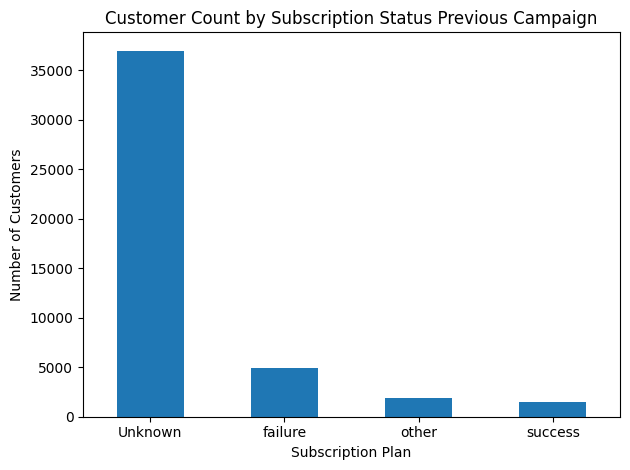

In [14]:
# Count the number of customers in each subscription plan
plan_counts = df["poutcome"].value_counts().sort_index()

# Print the frequency table for subscription plans
print("Subscription plan counts for Previous Campaign:")
print(plan_counts)

# Create a bar chart of subscription plan counts
plan_counts.plot(kind="bar")

# Add a title to the chart
plt.title("Customer Count by Subscription Status Previous Campaign")

# Add a label to the x-axis
plt.xlabel("Subscription Plan")

# Add a label to the y-axis
plt.ylabel("Number of Customers")

# Rotate x-axis labels so they are easier to read
plt.xticks(rotation=0)

# Adjust layout so labels fit better
plt.tight_layout()

# Show the chart
plt.show()

## Challenge to consider 

Dataset does not define what "other" means

Subscription plan counts:
y
no     39922
yes     5289
Name: count, dtype: int64


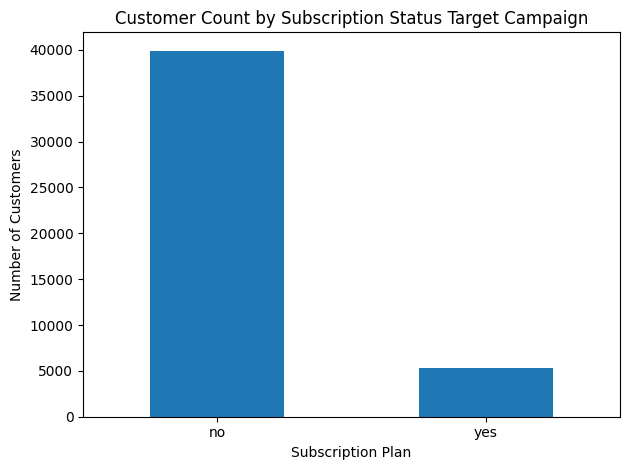

In [15]:
# Count the number of customers in each subscription plan
plan_counts = df["y"].value_counts().sort_index()

# Print the frequency table for subscription plans
print("Subscription plan counts:")
print(plan_counts)

# Create a bar chart of subscription plan counts
plan_counts.plot(kind="bar")

# Add a title to the chart
plt.title("Customer Count by Subscription Status Target Campaign")

# Add a label to the x-axis
plt.xlabel("Subscription Plan")

# Add a label to the y-axis
plt.ylabel("Number of Customers")

# Rotate x-axis labels so they are easier to read
plt.xticks(rotation=0)

# Adjust layout so labels fit better
plt.tight_layout()

# Show the chart
plt.show()

# Building Logistic Model

In [16]:
df["y"].value_counts()

y
no     39922
yes     5289
Name: count, dtype: int64

In [17]:
X = df.drop(columns=['y'], axis = 1)

X_converted = pd.get_dummies(X, drop_first=True)

y = df["y"]
# Print the shape of X to see the number of rows and predictor columns
print("X converted shape:", X_converted.shape)

# Print the shape of y to see the number of target values
print("y shape:", y.shape)



X converted shape: (45211, 42)
y shape: (45211,)


In [18]:
X.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome
0,58,management,married,tertiary,no,2143,yes,no,Unknown,5,may,261,1,-1,0,Unknown
1,44,technician,single,secondary,no,29,yes,no,Unknown,5,may,151,1,-1,0,Unknown
2,33,entrepreneur,married,secondary,no,2,yes,yes,Unknown,5,may,76,1,-1,0,Unknown
3,47,blue-collar,married,Unknown,no,1506,yes,no,Unknown,5,may,92,1,-1,0,Unknown
4,33,Unknown,single,Unknown,no,1,no,no,Unknown,5,may,198,1,-1,0,Unknown


In [19]:
X_converted.head()

,age,balance,day,duration,campaign,pdays,previous,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,marital_married,marital_single,education_primary,education_secondary,education_tertiary,default_yes,housing_yes,loan_yes,contact_cellular,contact_telephone,month_aug,month_dec,month_feb,month_jan,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_failure,poutcome_other,poutcome_success
0,58,2143,5,261,1,-1,0,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
1,44,29,5,151,1,-1,0,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,33,2,5,76,1,-1,0,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
3,47,1506,5,92,1,-1,0,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
4,33,1,5,198,1,-1,0,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


In [20]:

# Split X and y into training and test sets while preserving class balance as much as possible
X_train, X_test, y_train, y_test = train_test_split(
    X_converted, y, test_size=0.25, random_state=42, stratify=y
)

# Print the number of rows in the training set
print("Training rows:", len(X_train))

# Print the number of rows in the test set
print("Test rows:", len(X_test))

Training rows: 33908
Test rows: 11303


In [21]:
# Import LogisticRegression to build a classification model for a binary target
from sklearn.linear_model import LogisticRegression

# Import confusion_matrix, precision_score, recall_score, and accuracy_score for classification evaluation
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score

# Create a new logistic regression model object
log_model = LogisticRegression(max_iter=1000)

# Fit the model using the training predictors and training target values
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

/Users/trimac/.virtualenvs/ist360/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
# Metrics
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))

Confusion Matrix:
 [[9710  271]
 [ 879  443]]
Accuracy: 0.8982570998849863


ValueError: pos_label=1 is not a valid label. It should be one of ['no', 'yes']